In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize the dataset (values between 0 and 1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten the images (from 28x28 to 784)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))


In [3]:
input_dim = x_train.shape[1]  # Input size (784)
encoding_dim = 32  # Latent space dimension

# Input layer
input_img = Input(shape=(input_dim,))

# Encoder
encoded = Dense(encoding_dim, activation='relu')(input_img)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Full autoencoder model
autoencoder = Model(input_img, decoded)

# Encoder model
encoder = Model(input_img, encoded)

# Decoder model
encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))


In [4]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


In [5]:
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/50

235/235 [==============================] - 3s 6ms/step - loss: 0.2781 - val_loss: 0.1942
Epoch 2/50
235/235 [==============================] - 1s 6ms/step - loss: 0.1734 - val_loss: 0.1550
Epoch 3/50
235/235 [==============================] - 1s 6ms/step - loss: 0.1452 - val_loss: 0.1342
Epoch 4/50
235/235 [==============================] - 1s 6ms/step - loss: 0.1289 - val_loss: 0.1216
Epoch 5/50
235/235 [==============================] - 2s 8ms/step - loss: 0.1184 - val_loss: 0.1132
Epoch 6/50
235/235 [==============================] - 3s 12ms/step - loss: 0.1114 - val_loss: 0.1074
Epoch 7/50
235/235 [==============================] - 2s 10ms/step - loss: 0.1064 - val_loss: 0.1031
Epoch 8/50
235/235 [==============================] - 2s 10ms/step - loss: 0.1026 - val_loss: 0.0999
Epoch 9/50
235/235 [==============================] - 2s 8ms/step - loss: 0.0998 - val_loss: 0.0974
Epoch 10/50
235/235 [==============================] - 2s 8ms/step - loss: 0.0978 - val_loss: 0.

313/313 [==============================] - 1s 2ms/step


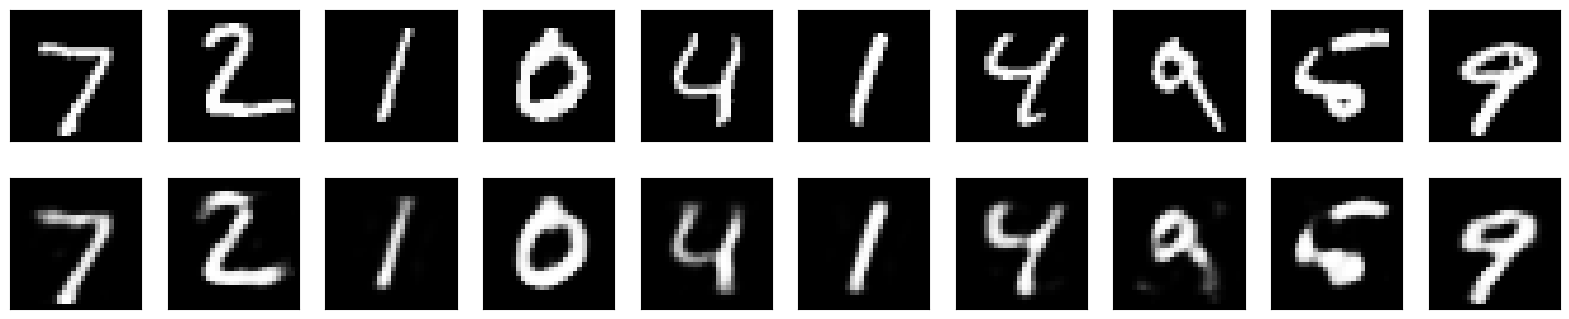

In [6]:
# Encode and decode test images
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

# Plot original and reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()
